In [1]:
# Setting up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

In [2]:
# Import Packages
from Input_Output_Rxn_Networks.IOCRN_MassAction import IOCRN_MassAction
from Input_Output_Rxn_Networks.ReactionSequenceGenerator import ReactionSequenceGenerator
import torch
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import types
import time
import imageio

In [3]:
# Select Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
# Define the dimensions of the CRN
num_species = 6
num_reactions = 20
num_inputs = 1
target_rank = 4

In [5]:
# Hyperparameters
N_samples = 1000                        # Number of samples to generate for Monte Carlo estimations
learning_rate = 0.001                   # Learning rate for the optimizer
entropy_weight = 0                      # Initial Entropy weight for the loss function
entropy_update_coefficient = 0.5        # Coefficient for updating the entropy weight
entropy_schedule = 1000                 # Number of epochs before updating the entropy weight
minimum_entropy_weight = 0.01           # Minimum entropy weight
num_epochs = 200                        # Number of epochs to train the model
Animation_Flag = True                   # Flag to generate animation of the training process


In [6]:
# Build the reaction sequence generator
MyRSG = ReactionSequenceGenerator(num_species, num_reactions, num_inputs, N_samples, LSTM_hidden_size=128, FFNN_hidden_size = [128, 128, 128], FFNN_num_layers = [5, 5, 5], weight=[None, None, None]).to(device)

In [7]:
def compute_loss(self, target_rank, h0, c0):
    stoichiometry_reactants, stoichiometry_products, _, total_logP, total_entropy, _, _ = self.forward(h0, c0)
    stoichiometry_matrix = stoichiometry_products - stoichiometry_reactants
    rank = np.linalg.matrix_rank(stoichiometry_matrix.astype(np.float32))
    loss_for_each_sample = np.abs(rank - target_rank)
    loss_for_each_sample = torch.tensor(loss_for_each_sample).to(h0)
    loss_mean = torch.mean(loss_for_each_sample)
    return loss_for_each_sample, loss_mean, total_logP, total_entropy
MyRSG.compute_loss = types.MethodType(compute_loss, MyRSG)

In [8]:
# Create the initialize plot function
def initialize_plot(width, height, dpi):
    # Add subplots
    fig = plt.figure(figsize=(width, height))
    fig.set_dpi(dpi)
    gs = gridspec.GridSpec(2, 2)
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    ax3 = fig.add_subplot(gs[1, 0])
    ax4 = fig.add_subplot(gs[1, 1])
    return fig, ax1, ax2, ax3, ax4

# Create the update plot function
def update_plot(fig, ax1, ax2, ax3, ax4, ranks, entropy_weight_history, loss_history, entropy_history):
    # Plot the results
    ax1.clear()
    ax1.hist(ranks, bins=range(1, ranks.max().item() + 2), align='left', rwidth=0.8)
    ax2.clear()
    ax2.plot(entropy_weight_history)
    ax3.clear()
    ax3.plot(loss_history)
    ax4.clear()
    ax4.plot(entropy_history)
    # Set the labels and titles
    ax1.set_xlabel('Rank')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Histogram of Stoichiometry Matrix Rank')
    ax2.set_xlabel('Epoch/100')
    ax2.set_ylabel('Entropy Weight')
    ax2.set_title('Entropy Weight History')
    ax3.set_xlabel('Epoch/100')
    ax3.set_ylabel('Loss')
    ax3.set_title('Loss History')
    ax4.set_xlabel('Epoch/100')
    ax4.set_ylabel('Entropy')
    ax4.set_title('Entropy History')
    # Set the axis scales
    ax2.set_yscale('log')
    ax3.set_yscale('log')
    ax4.set_yscale('log')
    # Adjust the layout
    plt.tight_layout()
    return fig

# Create the image writer
def update_frame(fig, frames):
    fig.canvas.draw()
    buffer, (width, height) = fig.canvas.print_to_buffer() 
    image = np.frombuffer(buffer, dtype='uint8').reshape((height, width, 4))  
    image = image[:, :, :3]  
    frames.append(image)
    return frames

In [9]:
# Train the reaction sequence generator

# logP0 = torch.log(torch.ones((PSG.num_samples,)) / PSG.grid_size)
# H0 = torch.log(torch.ones((PSG.num_samples,)) * PSG.grid_size)
h0 = torch.ones(MyRSG.num_samples, MyRSG.LSTM_hidden_size).float()
c0 = torch.ones(MyRSG.num_samples, MyRSG.LSTM_hidden_size).float()
optimizer = torch.optim.Adam(MyRSG.parameters(), lr=learning_rate)
loss_history = []
entropy_history = []
entropy_weight_history = []
frames = []
fig, ax1, ax2, ax3, ax4 = initialize_plot(width=14, height=7, dpi=100)
ranks_list = []
for epoch in range(num_epochs):
    optimizer.zero_grad()
    loss_for_each_sample, loss_mean, logPs, entropy = compute_loss(MyRSG, target_rank, h0, c0)
    entropy_mean = torch.mean(entropy)
    loss_for_gradient = torch.mean(loss_for_each_sample.detach() * logPs) - entropy_weight * entropy_mean - torch.mean(entropy_weight * entropy.detach() * logPs)
    loss_for_gradient.backward()
    optimizer.step()
    if epoch % 1 == 0:
        print('Epoch: %d, Mean Loss: %.4f, Entropy: %.4f, Entropy Weight: %.4f' % (epoch, loss_mean.item(), entropy_mean.item(), entropy_weight))
        if Animation_Flag:
            loss_history.append(loss_mean.item())
            entropy_history.append(entropy_mean.item())
            entropy_weight_history.append(entropy_weight)
            stoichiometry_reactants, stoichiometry_products, _, total_logP, total_entropy, _, _ = MyRSG(h0, c0)
            stoichiometry_matrix = stoichiometry_products - stoichiometry_reactants
            ranks = np.linalg.matrix_rank(stoichiometry_matrix)
            ranks_list.append(ranks)
            fig = update_plot(fig, ax1, ax2, ax3, ax4, ranks, entropy_weight_history, loss_history, entropy_history)
            frames = update_frame(fig, frames)
    if epoch % entropy_schedule == 0 and epoch != 0:
        entropy_weight = max(entropy_weight * entropy_update_coefficient, minimum_entropy_weight)

# Save the animation
if Animation_Flag:
    imageio.mimsave('Animation_Ranks.gif', frames, fps=10, loop=0)
    plt.close(fig)

Epoch: 0, Mean Loss: 1.9990, Entropy: 154.4066, Entropy Weight: 0.0000


/var/folders/xd/tf3ykp7j4751f249dt0jdsr80000gr/T/ipykernel_31898/1339409220.py:38: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2.set_yscale('log')


Epoch: 1, Mean Loss: 2.0000, Entropy: 154.3457, Entropy Weight: 0.0000
Epoch: 2, Mean Loss: 2.0000, Entropy: 154.2196, Entropy Weight: 0.0000
Epoch: 3, Mean Loss: 2.0000, Entropy: 153.9554, Entropy Weight: 0.0000
Epoch: 4, Mean Loss: 1.9990, Entropy: 153.3313, Entropy Weight: 0.0000
Epoch: 5, Mean Loss: 1.9990, Entropy: 152.4646, Entropy Weight: 0.0000
Epoch: 6, Mean Loss: 2.0000, Entropy: 151.0360, Entropy Weight: 0.0000
Epoch: 7, Mean Loss: 1.9990, Entropy: 149.7758, Entropy Weight: 0.0000
Epoch: 8, Mean Loss: 2.0000, Entropy: 149.3164, Entropy Weight: 0.0000
Epoch: 9, Mean Loss: 2.0000, Entropy: 148.0222, Entropy Weight: 0.0000
Epoch: 10, Mean Loss: 2.0000, Entropy: 147.2286, Entropy Weight: 0.0000
Epoch: 11, Mean Loss: 2.0000, Entropy: 146.7904, Entropy Weight: 0.0000
Epoch: 12, Mean Loss: 2.0000, Entropy: 146.5943, Entropy Weight: 0.0000
Epoch: 13, Mean Loss: 1.9990, Entropy: 145.6232, Entropy Weight: 0.0000
Epoch: 14, Mean Loss: 2.0000, Entropy: 145.3560, Entropy Weight: 0.0000
E

In [12]:
# Generate samples
stoichiometry_reactants, stoichiometry_products, _, total_logP, total_entropy, _, _ = MyRSG(h0, c0)
input_influence_matrix = torch.zeros(N_samples, num_reactions).long()

# Build the CRNs
parameters = np.ones(num_reactions, dtype=np.float32)
output_species = [num_species]
IOCRN = [None]*N_samples
for i in range(N_samples):
    IOCRN[i] = IOCRN_MassAction(stoichiometry_reactants[i], stoichiometry_products[i], parameters, input_influence_matrix, output_species)

# Print the reactions
species = ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
inputs = ['u']
i = 10
print('Sample', i+1, ':')
print('Input Influence Matrix:', input_influence_matrix[i])
IOCRN[i].print_reactions(species, inputs)
print('rank = ', np.linalg.matrix_rank(IOCRN[i].stoichiometry_matrix))
i = 50
print('Sample', i+1, ':')
print('Input Influence Matrix:', input_influence_matrix[i])
IOCRN[i].print_reactions(species, inputs)
print('rank = ', np.linalg.matrix_rank(IOCRN[i].stoichiometry_matrix))

Sample 11 :
Input Influence Matrix: tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
Inputs: ['u']
Species: ['X1', 'X2', 'X3', 'X4', 'X5', 'X6']
Output Species: ['X6']
Reaction 1: 2 X2 -> X1 + X4 ; Rate Constant: 1.0
Reaction 2: X2 + X4 -> 0 ; Rate Constant: 1.0
Reaction 3: X1 + X5 -> 0 ; Rate Constant: 1.0
Reaction 4: X4 + X5 -> X1 + X4 ; Rate Constant: 1.0
Reaction 5: 2 X2 -> 0 ; Rate Constant: 1.0
Reaction 6: X2 + X4 -> 0 ; Rate Constant: 1.0
Reaction 7: 2 X2 -> X1 + X4 ; Rate Constant: 1.0
Reaction 8: X2 + X4 -> 0 ; Rate Constant: 1.0
Reaction 9: X4 + X5 -> X1 + X4 ; Rate Constant: 1.0
Reaction 10: X4 + X5 -> 0 ; Rate Constant: 1.0
Reaction 11: X1 + X5 -> 0 ; Rate Constant: 1.0
Reaction 12: X1 + X4 -> X1 + X4 ; Rate Constant: 1.0
Reaction 13: 2 X2 -> X1 + X4 ; Rate Constant: 1.0
Reaction 14: X4 + X5 -> X1 + X4 ; Rate Constant: 1.0
Reaction 15: 2 X2 -> 0 ; Rate Constant: 1.0
Reaction 16: X4 + X5 -> X1 + X4 ; Rate Constant: 1.0
Reaction 17: X4 + X5 -> X1 + X4 ; Ra

In [15]:
def lexicographic_sort(matrix):
    """
    Perform lexicographic sorting on the matrix, first sorting rows and then columns.
    Repeat until the matrix no longer changes.
    """
    prev_matrix = None
    current_matrix = matrix

    while not np.array_equal(prev_matrix, current_matrix):
        prev_matrix = current_matrix.copy()
        current_matrix = np.array(sorted(current_matrix.tolist()))  # Sort rows lexicographically
        current_matrix = np.array(sorted(current_matrix.T.tolist())).T  # Sort columns lexicographically

    return torch.tensor(current_matrix)

def count_unique_permuted_matrices(matrices):
    canonical_forms = set()

    for mat in matrices:
        canonical_form = lexicographic_sort(mat)
        # Convert canonical form to a hashable type (tuple of tuples)
        canonical_form_tuple = tuple(map(tuple, canonical_form.tolist()))
        canonical_forms.add(canonical_form_tuple)
    
    return len(canonical_forms)

matrices = []
for i in range(N_samples):
    matrices.append(IOCRN[i].stoichiometry_matrix)

unique_count = count_unique_permuted_matrices(matrices)
print("Number of unique matrices considering permutations:", unique_count)

Number of unique matrices considering permutations: 998


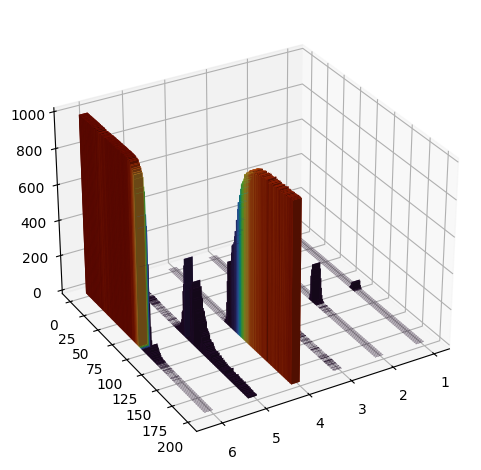

In [17]:
tensor_list = ranks_list

num_iterations = num_epochs
tensor_size = ranks.shape[0]

# Prepare data for 3D histogram
bins = np.arange(1, 8)  # Bins for values 1 to 6
hist_data = np.zeros((num_iterations, len(bins) - 1))

# Compute histogram for each tensor
for i, tensor in enumerate(tensor_list):
    hist, _ = np.histogram(tensor, bins=bins)
    hist_data[i] = hist

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Create the 3D histogram
xpos, ypos = np.meshgrid(np.arange(1, 7), np.arange(num_iterations))
xpos = xpos.flatten()
ypos = ypos.flatten()
zpos = np.zeros_like(xpos)

# Heights of the bars
dx = dy = 0.2
dz = hist_data.flatten()

import matplotlib.colors as mcolors
norm = mcolors.PowerNorm(gamma=5, vmin=0, vmax=1010)
colors = plt.cm.turbo(norm(dz))  # Use the normalized dz to map to a colormap



ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors, zsort='average')

# ax.set_xlabel('Rank')
# ax.set_ylabel('Epoch')
# ax.set_zlabel('Number of Networks')
ax.view_init(elev=30, azim=60)
plt.tight_layout()
plt.savefig('Rank_Evolution.pdf', format='pdf')
plt.show()